# 🤖 Machine Learning — Notebook de Projeto

**Disciplina:** Machine Learning  
**Professor:** Messias Batista  
**Aluno(a):**  
**Data:**  
**Dataset: Iris Species**  
**Problema de negócio: Identificar qual a espécie da flor**  


---
## 1. 📦 Importações

Importe aqui todas as bibliotecas que serão utilizadas ao longo do projeto.

Você precisará de bibliotecas para:
- **Manipulação de dados** — leitura, transformação e análise de tabelas
- **Visualização** — criação de gráficos e figuras
- **Pré-processamento** — divisão dos dados, normalização e codificação de variáveis
- **Algoritmos de Machine Learning** — os modelos que serão treinados
- **Métricas de avaliação** — para medir o desempenho dos modelos

In [1]:
# Escreva suas importações aqui
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

---
## 2. 📂 Carregamento dos Dados

Carregue o dataset e faça uma primeira inspeção para entender com o que você está trabalhando.

Nesta etapa você deve responder:
- Quantas linhas e colunas o dataset possui?
- Quais são os tipos de cada coluna?
- Existem valores nulos? Em quais colunas e em qual quantidade?

In [2]:
# Carregue o dataset aqui
iris = datasets.load_iris()

# iris.target           -> Variável alto # classes
# iris.data             -> Atributos / Características # dados
# iris.feature_names    -> Nomes dos atributos (colunas)

In [3]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [4]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
# Renomear as colunas

colunas = { 'sepal length (cm)': 'sepal_length',
            'sepal width (cm)': 'sepal_width',
            'petal length (cm)': 'petal_length',
            'petal width (cm)': 'petal_width'}


df = df.rename(columns=colunas)

In [6]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
# Adicionar o target
df['target'] = iris.target

In [8]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


A função map() em Python aplica uma função a cada elemento de um iterável — como uma lista ou tupla — e retorna um iterador com os resultados transformados. Pense nela como uma esteira de produção: cada item entra, passa por uma transformação e sai do outro lado modificado.


No contexto de pandas, a função map() é um método de Series que mapeia os valores de uma Series para outros valores usando um dicionário, uma função ou outra Series.

In [9]:
# Adicionar target_name
df['target_name'] = df.target.map(
    {0: 'setosa',
     1: 'versicolor',
     2: 'virginica'})

In [10]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [11]:
# Inspecione o dataset (dimensões, tipos e nulos)


---
## 3. 🔍 Análise Exploratória de Dados (EDA)

Explore os dados antes de construir qualquer modelo. Esta é uma das etapas mais importantes do processo.

Nesta etapa você deve:
- Calcular estatísticas descritivas das variáveis numéricas
- Analisar a distribuição da variável alvo (está balanceada?)
- Visualizar a distribuição das demais variáveis
- Identificar possíveis outliers
- Analisar a correlação entre as variáveis

In [ ]:
# Estatísticas descritivas


In [ ]:
# Distribuição da variável alvo


In [ ]:
# Visualizações (histogramas, boxplots, correlação)


---
## 4. 🛠️ Pré-processamento

Prepare os dados para que o modelo consiga aprender corretamente.

Nesta etapa você deve:
- Remover colunas que não contribuem para o modelo
- Tratar os valores nulos (remover ou preencher)
- Converter variáveis categóricas em numéricas
- Separar as features (X) da variável alvo (y)
- Aplicar normalização ou padronização se necessário

In [ ]:
# Limpeza e transformação dos dados


In [ ]:
# Separação de X (features) e y (target)


---
## 5. ✂️ Separação Treino / Teste

Divida os dados em dois conjuntos: um para treinar o modelo e outro para testá-lo.

Lembre-se:
- O modelo deve ser treinado **apenas** com os dados de treino
- Os dados de teste simulam situações novas, que o modelo nunca viu
- Uma divisão comum é 70% treino e 30% teste
- Use o parâmetro `stratify` para manter a proporção das classes

In [12]:
# 1 - Separar as características da saída
X = df.drop(columns=['target', 'target_name'])
y = df['target']

In [14]:
# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

---
## 6. 🧠 Treinamento do Modelo

Escolha um algoritmo, instancie o modelo e treine-o com os dados de treino.

Lembre-se:
- O treinamento acontece com o método `fit()`
- As previsões são feitas com o método `predict()`
- Você pode testar mais de um algoritmo e compará-los na seção 8

In [19]:
# Instancie e treine o modelo max_depth=3
clf_dt = DecisionTreeClassifier(max_depth=3, random_state=42)

In [20]:
clf_dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [21]:
# Gere as previsões para o conjunto de teste
previsoes = clf_dt.predict(X_test)
previsoes

array([2, 1, 2, 1, 2, 2, 1, 1, 0, 2, 0, 0, 2, 2, 0, 2, 1, 0, 0, 0, 1, 0,
       1, 2, 2, 1, 1, 1, 1, 0, 2, 2, 1, 0, 2, 0, 0, 0, 0, 2, 1, 0, 2, 2,
       1])

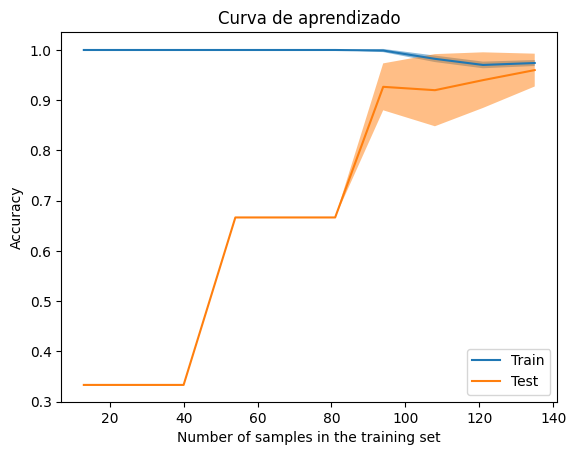

In [22]:
from sklearn.model_selection import LearningCurveDisplay
import numpy as np

LearningCurveDisplay.from_estimator(
    clf_dt, X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=10, scoring='accuracy', n_jobs=-1
)
plt.title('Curva de aprendizado')
plt.show()

In [ ]:
iris.feature_names

In [ ]:
import joblib
import sklearn
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('clf_dt', DecisionTreeClassifier(max_depth=3, random_state=42))
])
pipeline.fit(X_train, y_train)
print(f"Acurácia no teste: {pipeline.score(X_test, y_test):.4f}")

# Salva a pipeline inteira — preprocessing + modelo
joblib.dump(pipeline, 'modelo.joblib')
# Salve também metadados auxiliares
metadados = {
    'features': iris.feature_names,
    'classes': iris.target_names.tolist(),
    'sklearn_version': sklearn.__version__,
}
joblib.dump(metadados, 'metadados.joblib')

---
## 7. 📊 Avaliação do Modelo

Meça o desempenho do modelo utilizando métricas adequadas ao problema.

Para problemas de **classificação**, avalie:
- **Acurácia** — proporção de acertos em relação ao total
- **Matriz de Confusão** — visualização detalhada dos acertos e erros por classe
- **Relatório de Classificação** — precision, recall e f1-score por classe
- **Validação Cruzada** — para uma estimativa mais robusta e confiável do desempenho

In [ ]:
# Acurácia
acuracia = accuracy_score(y_test, previsoes)
print(f'Acurácia: {acuracia * 100}%')

In [ ]:
# Matriz de Confusão
cm = confusion_matrix(y_test, previsoes)
cm

In [ ]:
nomes_classes = iris.target_names  # ['setosa', 'versicolor', 'virginica']

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=nomes_classes,
    yticklabels=nomes_classes
)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.tight_layout()
plt.show()


In [ ]:
# Relatório de Classificação


In [ ]:
# Validação Cruzada


---
## 8. 🏆 Comparação de Modelos

Teste outros algoritmos e compare os resultados para identificar o mais adequado ao seu problema.

Dica: use validação cruzada para comparar os modelos de forma justa,
pois ela elimina o efeito da aleatoriedade de uma única divisão treino/teste.

In [ ]:
# Compare diferentes algoritmos aqui


---
## 9. 📝 Conclusões

Responda as perguntas abaixo com base nos resultados obtidos:

**1. Qual algoritmo apresentou melhor desempenho? Por quê?**  
> _Escreva aqui_

**2. O modelo está sofrendo overfitting ou underfitting? Como você identificou?**  
> _Escreva aqui_

**3. Os resultados respondem à pergunta de negócio levantada no início?**  
> _Escreva aqui_

**4. Qual seria o próximo passo para melhorar o modelo?**  
> _Escreva aqui_

---
### 🔖 Referências
- Dataset: _(cite a fonte)_
- Scikit-learn: https://scikit-learn.org
- Material da disciplina: www.mrafaelbatista.dev
